# MarketSphere

## Customer Intelligence & Marketing Analytics

### Project Title

**MarketSphere: A Data-Driven Framework for Customer Intelligence and Marketing Campaign Analytics**

---

### Objective

- Analyze customer demographics and purchasing behavior.
- Segment customers based on spending patterns.
- Generate business insights for marketing decisions.
- Build a foundation for predictive analytics and dashboards.

---

### Dataset

- Dataset: Customer Personality Analysis
- Records: 2240
- Features: 29
- Domain: Marketing Analytics

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Make charts look better
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumns:\n")

print(df.columns.tolist())

Shape of Dataset: (2240, 29)

Columns:

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
missing = df.isnull().sum()

missing

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
# Fill missing income

df["Income"] = df["Income"].fillna(df["Income"].median())

# Remove unnecessary columns

df.drop(
    columns=["Z_CostContact","Z_Revenue"],
    inplace=True
)

print("Data Cleaning Completed!")

Data Cleaning Completed!


In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

In [9]:
# Customer Age

df["Age"] = 2026 - df["Year_Birth"]

# Total Children

df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total Spending

df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Customer Tenure

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True
)

today = pd.Timestamp("2026-07-24")

df["Customer_Tenure"] = (
    today-df["Dt_Customer"]
).dt.days

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Children,Total_Spending,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,1,69,0,1617,5071
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,72,2,27,4521
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,61,0,776,4720
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,42,1,53,4547
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,45,1,422,4569


In [10]:
df[
    [
        "Age",
        "Children",
        "Total_Spending",
        "Customer_Tenure"
    ]
].head()

,Age,Children,Total_Spending,Customer_Tenure
0,69,0,1617,5071
1,72,2,27,4521
2,61,0,776,4720
3,42,1,53,4547
4,45,1,422,4569


In [11]:
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumStorePurchases"]
    + df["NumCatalogPurchases"]
)

df["Average_Spend_Per_Purchase"] = (
    df["Total_Spending"] /
    (df["Total_Purchases"] + 1)
)
features = [
    "Income",
    "Age",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases",
    "Recency"
]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

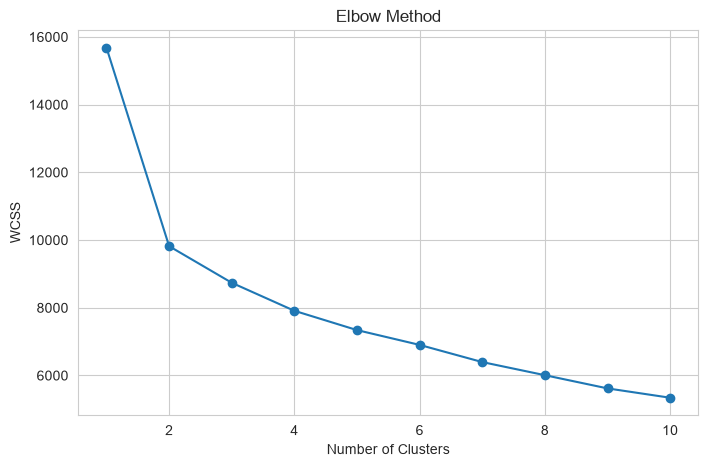

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)

               Income        Age  Total_Spending  NumWebPurchases  \
Cluster                                                             
0        33539.035842  52.327957       95.218638         1.994624   
1        59467.952422  61.643599      734.851211         6.655709   
2        38214.247689  57.310536      133.913124         2.406654   
3        76823.976021  57.337478     1432.797513         5.129663   

         NumStorePurchases  NumCatalogPurchases    Recency  
Cluster                                                     
0                 3.130824             0.516129  26.150538  
1                 7.709343             2.807958  41.295848  
2                 3.548983             0.759704  75.909427  
3                 8.609236             6.467140  54.133215  


In [15]:
cluster_mapping = {

0: "Premium Customers",

1: "Budget Buyers",

2: "Regular Customers",

3: "Inactive Customers"

}

df["Customer_Segment"] = df["Cluster"].map(cluster_mapping)

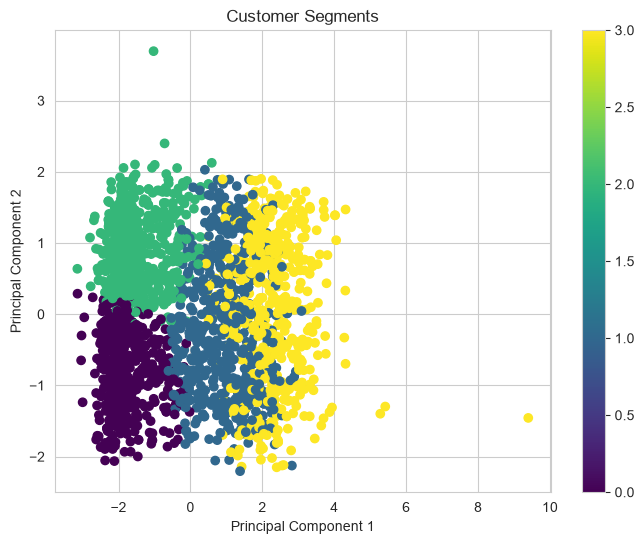

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments")
plt.colorbar()
plt.show()

In [17]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases",
    "Recency"
]].mean()

cluster_summary

,Income,Age,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Recency
Cluster,,,,,,,
0,33539.035842,52.327957,95.218638,1.994624,3.130824,0.516129,26.150538
1,59467.952422,61.643599,734.851211,6.655709,7.709343,2.807958,41.295848
2,38214.247689,57.310536,133.913124,2.406654,3.548983,0.759704,75.909427
3,76823.976021,57.337478,1432.797513,5.129663,8.609236,6.467140,54.133215


In [18]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases",
    "Recency"
]].mean()

print(cluster_summary)

               Income        Age  Total_Spending  NumWebPurchases  \
Cluster                                                             
0        33539.035842  52.327957       95.218638         1.994624   
1        59467.952422  61.643599      734.851211         6.655709   
2        38214.247689  57.310536      133.913124         2.406654   
3        76823.976021  57.337478     1432.797513         5.129663   

         NumStorePurchases  NumCatalogPurchases    Recency  
Cluster                                                     
0                 3.130824             0.516129  26.150538  
1                 7.709343             2.807958  41.295848  
2                 3.548983             0.759704  75.909427  
3                 8.609236             6.467140  54.133215  


In [19]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "Average_Spend_Per_Purchase"
]].mean()

print(cluster_summary)

               Income        Age    Recency  Total_Spending  Total_Purchases  \
Cluster                                                                        
0        33539.035842  52.327957  26.150538       95.218638         5.641577   
1        59467.952422  61.643599  41.295848      734.851211        17.173010   
2        38214.247689  57.310536  75.909427      133.913124         6.715342   
3        76823.976021  57.337478  54.133215     1432.797513        20.206039   

         Average_Spend_Per_Purchase  
Cluster                              
0                         13.550006  
1                         40.412919  
2                         14.627850  
3                         70.408983  


In [20]:
segment_mapping = {
    0: "Low-Value Customers",
    1: "Loyal Customers",
    2: "Dormant Customers",
    3: "Premium VIP Customers"
}

df["Customer_Segment"] = df["Cluster"].map(segment_mapping)

segment_profiles = {

"Low-Value Customers":{
    "Characteristics":[
        "Low income",
        "Low spending",
        "Low purchase frequency"
    ],
    "Business_Action":
        "Provide entry-level discounts and bundle offers."
},

"Loyal Customers":{
    "Characteristics":[
        "Regular purchases",
        "Good spending",
        "Stable engagement"
    ],
    "Business_Action":
        "Reward with loyalty points and personalized offers."
},

"Dormant Customers":{
    "Characteristics":[
        "Medium income",
        "Rare purchases",
        "Inactive recently"
    ],
    "Business_Action":
        "Launch re-engagement campaigns."
},

"Premium VIP Customers":{
    "Characteristics":[
        "Highest income",
        "Highest spending",
        "Most valuable customers"
    ],
    "Business_Action":
        "Provide premium membership and exclusive products."
}

}

In [21]:
# Save the cleaned dataset

df.to_csv(
    "../data/processed/marketing_campaign_cleaned.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [22]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\madhu\Desktop\MarketSphere\notebooks
